In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# Step 3 : Multi-Peak-Track and Event Building

The final step in reconstruction is grouping different associated bands into single multi-peak-tracks and grouping different multi-peak-tracks into single events if they correspond to the same electron:

```yaml
      - signal: "tr-proc-ws:track"
        slot: "mptb:track"
      - signal: "itc:clustering-done"
        slot: "mptb:do-clustering"
      - signal: "mptb:mpt"
        slot: "mpeb:mpt"
      - signal: "mptb:mpt-done"
        slot: "mpeb:do-clustering"
      - signal: "mpeb:event"
```

There are also some cuts applied at this last stage in an attempt to filter out noise events:

```yaml
        slot: "event-nup-cut:apply"
      - signal: "event-nup-cut:pass"
        slot: "event-time-cut:apply"
      - signal: "event-time-cut:pass"
        slot: "treewriter:mt-event"              # Write processed multi-peak-track events
```

This is where Phase II reconstruction ends and Phase III reconstruction development begins. The last section of this notebooks starts exploring this development by suggesting an axial frequency reconstruction algorithm. 

To explore the structure of event data, we will plot CRES tracks as we did before.

In [2]:
treeFile = uproot.open('eventBuilding_tree.root')
treeFile.classnames()

{'discPoints1D;2': 'TTree',
 'discPoints1D;1': 'TTree',
 'multiTrackEvents;2': 'TTree',
 'multiTrackEvents;1': 'TTree'}

In [3]:
eventsTree = treeFile['multiTrackEvents;1']
eventsTree.keys()

['Event',
 'Event/TObject',
 'Event/TObject/fUniqueID',
 'Event/TObject/fBits',
 'Event/fComponent',
 'Event/fAcquisitionID',
 'Event/fEventID',
 'Event/fTotalEventSequences',
 'Event/fStartTimeInRunC',
 'Event/fStartTimeInAcq',
 'Event/fEndTimeInRunC',
 'Event/fTimeLength',
 'Event/fStartFrequency',
 'Event/fEndFrequency',
 'Event/fMinimumFrequency',
 'Event/fMaximumFrequency',
 'Event/fFrequencyWidth',
 'Event/fStartTimeInRunCSigma',
 'Event/fEndTimeInRunCSigma',
 'Event/fTimeLengthSigma',
 'Event/fStartFrequencySigma',
 'Event/fEndFrequencySigma',
 'Event/fFrequencyWidthSigma',
 'Event/fFirstTrackID',
 'Event/fFirstTrackTimeLength',
 'Event/fFirstTrackFrequencyWidth',
 'Event/fFirstTrackSlope',
 'Event/fFirstTrackIntercept',
 'Event/fFirstTrackTotalPower',
 'Event/fFirstTrackNTrackBins',
 'Event/fFirstTrackTotalSNR',
 'Event/fFirstTrackMaxSNR',
 'Event/fFirstTrackTotalNUP',
 'Event/fFirstTrackMaxNUP',
 'Event/fFirstTrackTotalWideSNR',
 'Event/fFirstTrackTotalWideNUP',
 'Event/fUnkno

In [4]:
data = {}
data['eventsData'] = {}

eventsTreeBranches = ['Event/fEventID', 'Event/fTotalEventSequences',
                      'Event/fTracks', 'Event/fTracks/fTracks.fUniqueID', 'Event/fTracks/fTracks.fAcquisitionID',
                      'Event/fTracks/fTracks.fTrackID', 'Event/fTracks/fTracks.fEventID', 'Event/fTracks/fTracks.fEventSequenceID',
                      'Event/fTracks/fTracks.fIsCut', 'Event/fTracks/fTracks.fStartTimeInRunC', 'Event/fTracks/fTracks.fStartTimeInAcq',
                      'Event/fTracks/fTracks.fEndTimeInRunC', 'Event/fTracks/fTracks.fTimeLength', 'Event/fTracks/fTracks.fStartFrequency',
                      'Event/fTracks/fTracks.fEndFrequency', 'Event/fTracks/fTracks.fSlope', 'Event/fTracks/fTracks.fIntercept',
                      'Event/fTracks/fTracks.fTotalPower', 'Event/fTracks/fTracks.fNTrackBins', 'Event/fTracks/fTracks.fTotalTrackSNR', 
                      'Event/fTracks/fTracks.fMaxTrackSNR', 'Event/fTracks/fTracks.fTotalTrackNUP', 'Event/fTracks/fTracks.fMaxTrackNUP', 
                      'Event/fTracks/fTracks.fTotalWideTrackSNR', 'Event/fTracks/fTracks.fTotalWideTrackNUP',]

data['eventsData'] = eventsTree.arrays(eventsTreeBranches, library='np')

In [5]:
totalEventIDs = data['eventsData']['Event/fEventID']
totalSequences = data['eventsData']['Event/fTotalEventSequences']

tracksIDs = data['eventsData']['Event/fTracks/fTracks.fTrackID'][0]
tracksEventIDs = data['eventsData']['Event/fTracks/fTracks.fEventID'][0]
tracksEventSeqIDs = data['eventsData']['Event/fTracks/fTracks.fEventSequenceID'][0]
tracksIsCut = data['eventsData']['Event/fTracks/fTracks.fIsCut'][0]
tracksStartTimes = data['eventsData']['Event/fTracks/fTracks.fStartTimeInRunC'][0]
tracksEndTimes = data['eventsData']['Event/fTracks/fTracks.fEndTimeInRunC'][0]
tracksStartFrequencies = data['eventsData']['Event/fTracks/fTracks.fStartFrequency'][0]
tracksEndFrequencies = data['eventsData']['Event/fTracks/fTracks.fEndFrequency'][0]
tracksSlopes = data['eventsData']['Event/fTracks/fTracks.fSlope'][0]
tracksIntercepts = data['eventsData']['Event/fTracks/fTracks.fIntercept'][0]


Multi-peak-tracks corresponding to single electrons are stored in events and tagged with a specific `EventID`. The data analyzed here does not include scattering; however, if there are multiple scattered tracks their ordering in the event is tagged by `EventSequenceID`. Although there is only one event and one multi-peak track in the data we are looking at here, we will write code as if there were multiple events and multiple multi-peak-tracks. This will help us develop an axial frequency reconstruction algorithm that we can implement in Katydid. 

Now, we iterate through the events and tracks within those events, look at the first multi-peak-track, and try to reconstruct the axial frequency. Before that, let us just plot the CRES tracks again with their intercepts using the iteration just mentioned.

Text(0, 0.5, 'Frequency [Hz]')

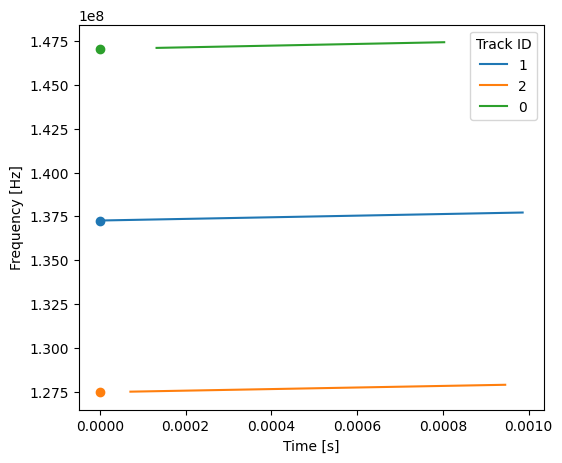

In [6]:
fig, ax = plt.subplots(figsize=(6,5))
for eventID in totalEventIDs:
    # trackIDs are no longer properly ordered, iterate through as list
    for i in range(len(tracksIDs)):
        # only looking at tracks that correspond to the same event and only interested in first multi-peak track in event
        if (tracksEventIDs[i]==eventID) & (tracksEventSeqIDs[i]==0):
                trackTimes = np.linspace(tracksStartTimes[i], tracksEndTimes[i], 100)
                trackFreqs = tracksSlopes[i]*trackTimes + tracksIntercepts[i]
                ax.plot(trackTimes, trackFreqs, label=tracksIDs[i])
                ax.scatter(0, tracksIntercepts[i], label='')


ax.legend(title='Track ID')
# ax.set_xlim([0,3.1e-3])
# ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')

We can use the intercepts to reconstruct axial frequency! The distance between the intercepts is some multiple $m$ of twice the axial frequency (ie. $m*2 f_{\text{axial}}$). Here is an algorithm for reconstruction:

1. Calculate all unique frequency distances between intercepts 
2. Calculate associated separation order associated to frequency distance
   - Divide all frequency distances by the minimum frequency distance and round result to nearest integer
3. Convert frequency distances to axial frequencies
   - Divide all frequency distances by their twice the separation order (because minimum distance is $2 f_{\text{axial}}$)
5. Average all axial frequencies

Recontsructed axial frequency = 4889917.400214896 Hz


Text(0, 0.5, 'Frequency [Hz]')

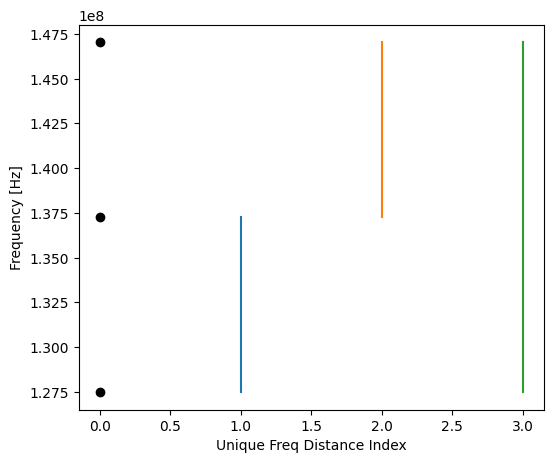

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
for eventID in totalEventIDs:
    freqDistances = []
    coveredIDs = []
    uniqueFreqDist = 0
    # trackIDs are not longer properly ordered, iterate through as list
    for i in range(len(tracksIDs)):
        # only looking at tracks that correspond to the same event and only interested in first multi-peak track in event
        if (tracksEventIDs[i]==eventID) & (tracksEventSeqIDs[i]==0):
            ax.scatter(0, tracksIntercepts[i], color='k', label='')
            for j in range(len(tracksIDs)):
                # same track conditions and only keeping unique permutations of IDs
                if (j!=i) & (j not in coveredIDs) & (tracksEventIDs[j]==eventID) & (tracksEventSeqIDs[j]==0):
                    uniqueFreqDist += 1
                    lineSegment = np.linspace(tracksIntercepts[i], tracksIntercepts[j], 100)
                    uniqueFreqDistArr = np.ones(100)*uniqueFreqDist
                    freqDist = np.abs(tracksIntercepts[i] - tracksIntercepts[j])
                    freqDistances.append(freqDist)
                    ax.plot(uniqueFreqDistArr, lineSegment, label=freqDist)
        coveredIDs.append(i)

min_fax = min(freqDistances)
separationOrder = np.rint(np.array(freqDistances)/min_fax)
all_fax = np.array(freqDistances)/(2*separationOrder)
averaged_fax = np.mean(all_fax)

print('Recontsructed axial frequency = ' + str(averaged_fax) + ' Hz')

# ax.set_xlim([0,3.1e-3])
# ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Unique Freq Distance Index')
ax.set_ylabel('Frequency [Hz]')

Now, we move onto Katydid development. Implement the algorithm above in Katydid. For guidance, you will need:

- A new Katydid data type to store the data after processing multi-peak-track-events (ie. storing reconstructed axial frequency)
- A new processor to perform the axial frequency reconstruction algorithm (ie. processor takes in multi-peak-track-events and returns new data type above with reconstructed axial frequency)